Load Era5 hourly data, pressure data for calculating wind shear

In [1]:
import sys
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append("..")

from src.data.load_era5 import load_era5, convert_longitude, subset_area

# Load all three datasets
ds = load_era5("../data/raw/era5_sample")
ds_pressure = load_era5("../data/raw/era5_pressure_sample.nc")
ds_cape = load_era5("../data/raw/era5_cape_sample.nc")

# Clean up wind pressure 
ds_pressure = convert_longitude(ds_pressure)
ds_pressure = subset_area(ds_pressure, north=60, south=48, west=-10, east=2)

# Clean up cape
ds_cape = convert_longitude(ds_cape)
ds_cape = subset_area(ds_cape, north=60, south=48, west=-10, east=2)

# Merge everything into one dataset
ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", ascending=False)
print(ds_merged)

/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
/home/alf_walks/projects/python/HPCWeatherPredictionPipeline/notebooks/../src/data/load_era5.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitl

<xarray.Dataset> Size: 4MB
Dimensions:         (valid_time: 12, latitude: 49, longitude: 49,
                     pressure_level: 8)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 96B 2020-01-01 ... 2020-01-03...
    expver          (valid_time) <U4 192B '0001' '0001' '0001' ... '0001' '0001'
  * latitude        (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude       (longitude) float64 392B -10.0 -9.75 -9.5 ... 1.5 1.75 2.0
  * pressure_level  (pressure_level) float64 64B 1e+03 925.0 ... 400.0 300.0
    number          int64 8B 0
Data variables:
    u10             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    v10             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    d2m             (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    t2m             (valid_time, latitude, longit

/tmp/ipykernel_80999/189555802.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", ascending=False)
/tmp/ipykernel_80999/189555802.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge([ds, ds_pressure, ds_cape]).sortby("pressure_level", asc

Calcuate bulk wind shear

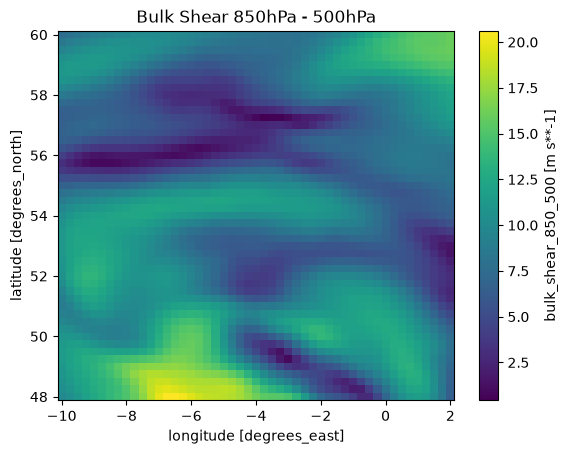

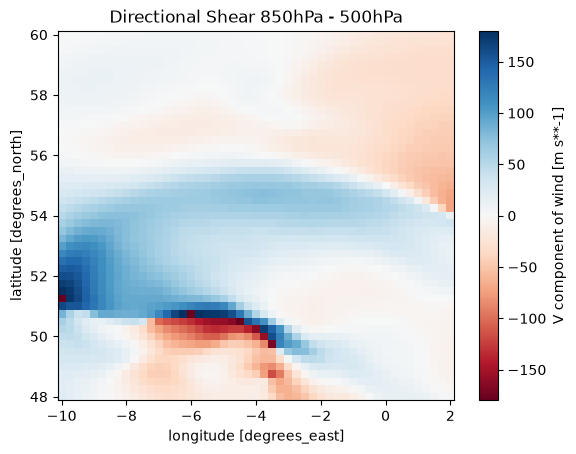

In [2]:
import sys
import xarray as xr
import matplotlib.pyplot as plt
sys.path.append("..")

from src.data.load_era5 import load_era5, convert_longitude, subset_area
from src.features.meteorology import compute_shear_features

# compute all shear features
shear_features = compute_shear_features(ds_merged)

fig1, ax1 = plt.subplots()
shear_features['bulk_shear_850_500'].isel(valid_time=0).plot(ax=ax1)
ax1.set_title("Bulk Shear 850hPa - 500hPa")

fig2, ax2 = plt.subplots()
shear_features['dir_shear_850_500'].isel(valid_time=0).plot(ax=ax2, cmap="RdBu", vmin=-180, vmax=180)
ax2.set_title("Directional Shear 850hPa - 500hPa")

plt.show()

Calculate Convective Available Potential Energy (CAPE)

In [ ]:
from src.features.meteorology import compute_cape

xrCape = compute_cape(ds_merged)
print(xrCape)


<xarray.Dataset> Size: 462kB
Dimensions:             (valid_time: 12, latitude: 49, longitude: 49)
Coordinates:
  * valid_time          (valid_time) datetime64[ns] 96B 2020-01-01 ... 2020-0...
    expver              (valid_time) <U4 192B '0001' '0001' ... '0001' '0001'
  * latitude            (latitude) float64 392B 60.0 59.75 59.5 ... 48.25 48.0
  * longitude           (longitude) float64 392B -10.0 -9.75 -9.5 ... 1.75 2.0
    number              int64 8B 0
    pressure_level      float64 8B 850.0
Data variables:
    bulk_shear_10m_850  (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    bulk_shear_850_500  (valid_time, latitude, longitude) float32 115kB 7.574...
    dir_shear_10m_850   (valid_time, latitude, longitude) float32 115kB dask.array<chunksize=(12, 49, 49), meta=np.ndarray>
    dir_shear_850_500   (valid_time, latitude, longitude) float32 115kB -0.53...
